<a href="https://colab.research.google.com/github/lucasm9302/EDA_Tesis/blob/main/EDA_Casi_Final_recup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bloque 1: Importación de librerías y carga de datos

In [ ]:
# 1. Agreguemos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder
import io


import os
# Crear carpeta para guardar imágenes automáticamente
os.makedirs('/content/imagenes_eda', exist_ok=True)

# Ignorar advertencias de futuras versiones
warnings.filterwarnings('ignore')

# 2. Carguemos los datos
df = pd.read_csv('/content/acData.csv')
print("Datos cargados. Dimensiones:", df.shape)

#Descripción e info preliminar
print(df.head().to_latex())
print(df.tail().to_latex())


Datos cargados. Dimensiones: (2466, 12)
\begin{tabular}{lrllrllrlllrr}
\toprule
 & countryCode & customerID & PaperlessDate & invoiceNumber & InvoiceDate & DueDate & InvoiceAmount & Disputed & SettledDate & PaperlessBill & DaysToSettle & DaysLate \\
\midrule
0 & 391 & 0379-NEVHP & 4/6/2013 & 611365 & 1/2/2013 & 2/1/2013 & 55.940000 & No & 1/15/2013 & Paper & 13 & 0 \\
1 & 406 & 8976-AMJEO & 3/3/2012 & 7900770 & 1/26/2013 & 2/25/2013 & 61.740000 & Yes & 3/3/2013 & Electronic & 36 & 6 \\
2 & 391 & 2820-XGXSB & 1/26/2012 & 9231909 & 7/3/2013 & 8/2/2013 & 65.880000 & No & 7/8/2013 & Electronic & 5 & 0 \\
3 & 406 & 9322-YCTQO & 4/6/2012 & 9888306 & 2/10/2013 & 3/12/2013 & 105.920000 & No & 3/17/2013 & Electronic & 35 & 5 \\
4 & 818 & 6627-ELFBK & 11/26/2012 & 15752855 & 10/25/2012 & 11/24/2012 & 72.270000 & Yes & 11/28/2012 & Paper & 34 & 4 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrllrllrlllrr}
\toprule
 & countryCode & customerID & PaperlessDate & invoiceNumber & InvoiceDate & DueDat

### Bloque 2: Ingeniería de Características (Feature Engineering)

Antes de explorar, construimos el historial de los clientes y las ventanas temporales para evitar la fuga de datos.

In [ ]:
# Convertimos fechas a formato datetime
date_cols = ['InvoiceDate', 'DueDate', 'PaperlessDate', 'SettledDate']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print([col] , df[col].dtype)


# Ordenamos cronológicamente (para variables históricas)
df = df.sort_values(by=['customerID', 'InvoiceDate']).reset_index(drop=True)
print(df.head(10).to_latex())

# -CREACIÓN DE VARIABLES-
# Variable Objetivo
df['Target_EsAtrasado'] = (df['DaysLate'] > 0).astype(int)

# Transformaciones básicas
df['PaperlessBill_Bin'] = (df['PaperlessBill'] == 'Electronic').astype(int)
df['Disputed_Bin'] = (df['Disputed'] == 'Yes').astype(int)
df['countryCode'] = df['countryCode'].astype(str) # Se trata como categoría

# Variables temporales
df['Plazo_Pago'] = (df['DueDate'] - df['InvoiceDate']).dt.days
df['Dias_Desde_Paperless'] = (df['InvoiceDate'] - df['PaperlessDate']).dt.days
df['Dias_Desde_Paperless'] = df['Dias_Desde_Paperless'].clip(lower=0)
df['Mes_Emision'] = df['InvoiceDate'].dt.month
df['Dia_Semana_Vencimiento'] = df['DueDate'].dt.dayofweek

# Historial del cliente (Window Functions con .shift(1))
df['Tasa_Atraso_Historico'] = df.groupby('customerID')['Target_EsAtrasado'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
df['Promedio_Dias_Atraso_Historico'] = df.groupby('customerID')['DaysLate'].transform(lambda x: x.shift(1).expanding().mean()).fillna(0)
df['Facturas_Disputadas_Pasadas'] = df.groupby('customerID')['Disputed_Bin'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
df['Facturas_Totales_Pasadas'] = df.groupby('customerID').cumcount()

# PRIMERA LIMPIEZA
# Eliminamos columnas que causan fuga de datos o son identificadores
columnas_a_eliminar = [
    'customerID', 'invoiceNumber', 'SettledDate', 'DaysToSettle', 'DaysLate',
    'PaperlessDate', 'PaperlessBill', 'Disputed', 'InvoiceDate', 'DueDate'
]
df_eda = df.drop(columns=columnas_a_eliminar)

['InvoiceDate'] datetime64[ns]
['DueDate'] datetime64[ns]
['PaperlessDate'] datetime64[ns]
['SettledDate'] datetime64[ns]
\begin{tabular}{lrllrllrlllrr}
\toprule
 & countryCode & customerID & PaperlessDate & invoiceNumber & InvoiceDate & DueDate & InvoiceAmount & Disputed & SettledDate & PaperlessBill & DaysToSettle & DaysLate \\
\midrule
0 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 4037644863 & 2012-03-29 00:00:00 & 2012-04-28 00:00:00 & 62.680000 & Yes & 2012-04-25 00:00:00 & Paper & 27 & 0 \\
1 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 9471530987 & 2012-05-15 00:00:00 & 2012-06-14 00:00:00 & 77.190000 & No & 2012-05-28 00:00:00 & Paper & 13 & 0 \\
2 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 9744145268 & 2012-05-21 00:00:00 & 2012-06-20 00:00:00 & 51.650000 & No & 2012-06-04 00:00:00 & Paper & 14 & 0 \\
3 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 7214076449 & 2012-06-16 00:00:00 & 2012-07-16 00:00:00 & 64.470000 & Yes & 2012-07-04 00:00:00 & Paper & 18 & 0 \\
4 & 391 & 0187-ERLSR 

### Bloque 3: Inspección inicial del Dataset

Verificamos la estructura y la calidad de los datos.

In [ ]:
# 3. y 4. Mostrar las primeras y últimas filas
print(df.head().to_latex())
print(df.tail().to_latex())

# # 5. Información del dataset
# df_eda.info()

# # 6. Veamos los datos faltantes o NaNs
# missing_values = df_eda.isna().sum()
# total_rows = df_eda.shape[0]
# missing_info_df = pd.DataFrame({
#     'Datos faltantes': missing_values,
#     'Porcentaje (%)': round((missing_values / total_rows) * 100, 2)
# })
# display(missing_info_df)

# 5. Información del dataset (Equivalente a df.info organizado para LaTeX)
info_df = pd.DataFrame({
    'Conteo No Nulos': df_eda.notna().sum(),
    'Tipo de Dato': df_eda.dtypes
})
print("--- Información del Dataset en LaTeX ---")
print(info_df.to_latex(caption="Información del Dataset", label="tab:info_dataset"))

# 6. Veamos los datos faltantes o NaNs organizados para LaTeX
missing_values = df_eda.isna().sum()
total_rows = df_eda.shape[0]
missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_values,
    'Porcentaje (%)': round((missing_values / total_rows) * 100, 2)
})
print("\n--- Datos Faltantes en LaTeX ---")
print(missing_info_df.to_latex(caption="Resumen de Datos Faltantes", label="tab:faltantes"))

\begin{tabular}{llllrllrlllrrrrrrrrrrrrr}
\toprule
 & countryCode & customerID & PaperlessDate & invoiceNumber & InvoiceDate & DueDate & InvoiceAmount & Disputed & SettledDate & PaperlessBill & DaysToSettle & DaysLate & Target_EsAtrasado & PaperlessBill_Bin & Disputed_Bin & Plazo_Pago & Dias_Desde_Paperless & Mes_Emision & Dia_Semana_Vencimiento & Tasa_Atraso_Historico & Promedio_Dias_Atraso_Historico & Facturas_Disputadas_Pasadas & Facturas_Totales_Pasadas \\
\midrule
0 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 4037644863 & 2012-03-29 00:00:00 & 2012-04-28 00:00:00 & 62.680000 & Yes & 2012-04-25 00:00:00 & Paper & 27 & 0 & 0 & 0 & 1 & 30 & 0 & 3 & 5 & 0.000000 & 0.000000 & 0.000000 & 0 \\
1 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 9471530987 & 2012-05-15 00:00:00 & 2012-06-14 00:00:00 & 77.190000 & No & 2012-05-28 00:00:00 & Paper & 13 & 0 & 0 & 0 & 0 & 30 & 0 & 5 & 3 & 0.000000 & 0.000000 & 1.000000 & 1 \\
2 & 391 & 0187-ERLSR & 2013-07-31 00:00:00 & 9744145268 & 2012-05-21 00:00:

### Bloque 4: Resumen Estadístico

Calculamos las métricas descriptivas para la variable respuesta, variables numéricas y categóricas

In [ ]:
# Definición estadística explícita de variables
vars_categoricas = ['Target_EsAtrasado', 'PaperlessBill_Bin', 'Disputed_Bin',
                    'Mes_Emision', 'Dia_Semana_Vencimiento', 'countryCode']

vars_numericas = ['InvoiceAmount', 'Plazo_Pago', 'Dias_Desde_Paperless',
                  'Tasa_Atraso_Historico', 'Promedio_Dias_Atraso_Historico',
                  'Facturas_Disputadas_Pasadas','Facturas_Totales_Pasadas'
                  ]

# 7. Resumen estadístico de las variables NUMÉRICAS independientes
print("--- Variables Numéricas Predictoras ---")
display(df_eda[vars_numericas].describe().T)

# 8. y 9. Resumen estadístico de las variables CATEGÓRICAS (Tablas de frecuencia)
print("\n--- Variables Categóricas (Frecuencias) ---")
for col in vars_categoricas:
    conteo = df_eda[col].value_counts()
    proporciones = df_eda[col].value_counts(normalize=True) * 100
    resumen = pd.DataFrame({'Conteo': conteo, 'Proporción (%)': proporciones})
    print(f"\nVariable: {col}")
    display(resumen)

--- Variables Numéricas Predictoras ---


,count,mean,std,min,25%,50%,75%,max
InvoiceAmount,2466.0,59.895856,20.435838,5.26,46.4,60.560000,73.765000,128.28
Plazo_Pago,2466.0,30.000000,0.000000,30.00,30.0,30.000000,30.000000,30.00
Dias_Desde_Paperless,2466.0,107.838605,153.649325,0.00,0.0,0.000000,193.000000,676.00
Tasa_Atraso_Historico,2466.0,0.376220,0.366115,0.00,0.0,0.250000,0.705882,1.00
Promedio_Dias_Atraso_Historico,2466.0,3.804777,4.847962,0.00,0.0,1.589572,6.424370,31.00
Facturas_Disputadas_Pasadas,2466.0,2.790349,4.261560,0.00,0.0,1.000000,4.000000,26.00
Facturas_Totales_Pasadas,2466.0,12.287510,7.882586,0.00,6.0,12.000000,18.000000,35.00



--- Variables Categóricas (Frecuencias) ---

Variable: Target_EsAtrasado


,Conteo,Proporción (%)
Target_EsAtrasado,,
0,1589,64.436334
1,877,35.563666



Variable: PaperlessBill_Bin


...

,Conteo,Proporción (%)
Mes_Emision,,
9,240,9.732360
5,237,9.610706
3,223,9.042985
11,217,8.799676
7,216,8.759124
4,209,8.475264
8,205,8.313058
10,202,8.191403
1,201,8.150852



Variable: Dia_Semana_Vencimiento


,Conteo,Proporción (%)
Dia_Semana_Vencimiento,,
0,378,15.328467
4,365,14.801298
6,352,14.274128
2,347,14.071371
1,346,14.030819
3,342,13.868613
5,336,13.625304



Variable: countryCode


,Conteo,Proporción (%)
countryCode,,
391,616,24.979724
406,561,22.749392
770,506,20.519059
897,396,16.058394
818,387,15.693431


### Bloque 5: Visualizaciones Univariadas

Generamos histogramas y diagramas de caja iterativos, extrayendo asimetría y curtosis.

Columna: InvoiceAmount
Asimetría (Skew): -0.12
Curtosis: -0.1


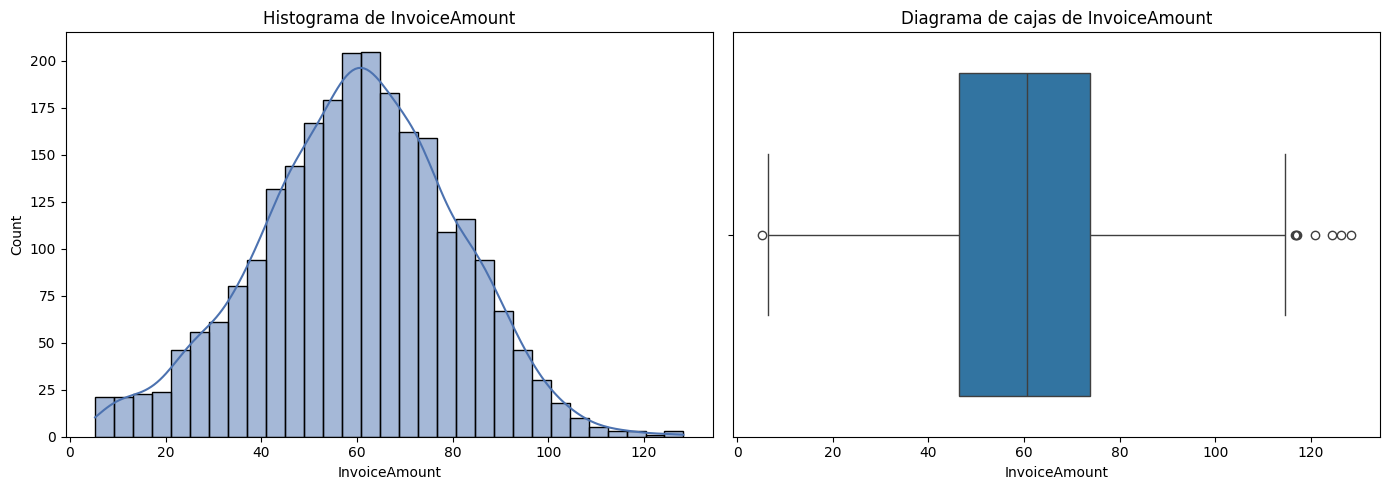

Columna: Plazo_Pago
Asimetría (Skew): 0.0
Curtosis: 0.0


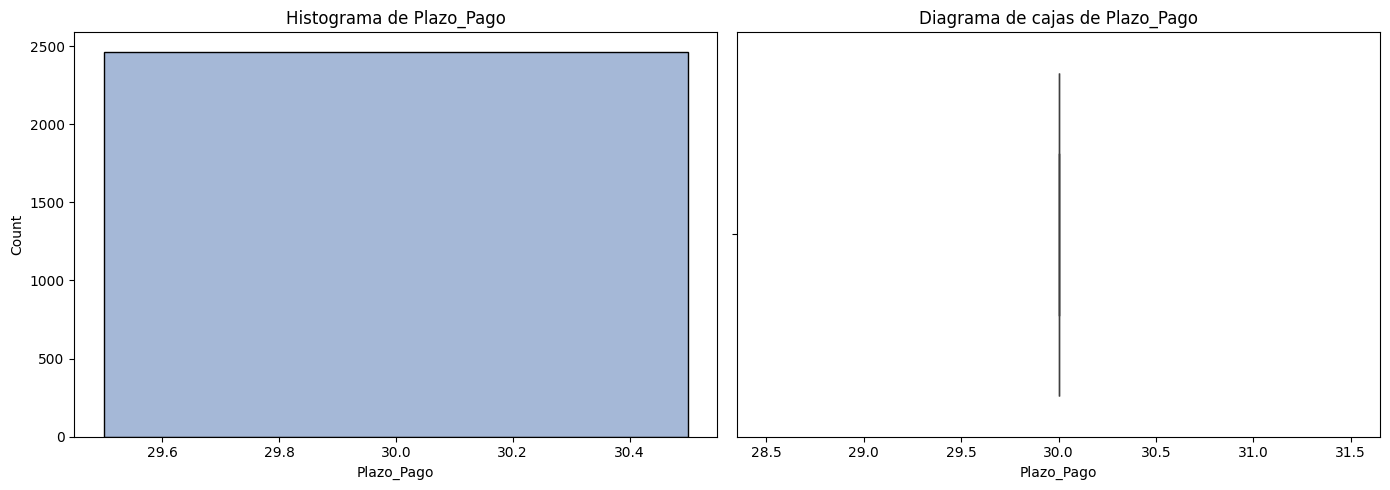

Columna: Dias_Desde_Paperless
Asimetría (Skew): 1.36
Curtosis: 0.83


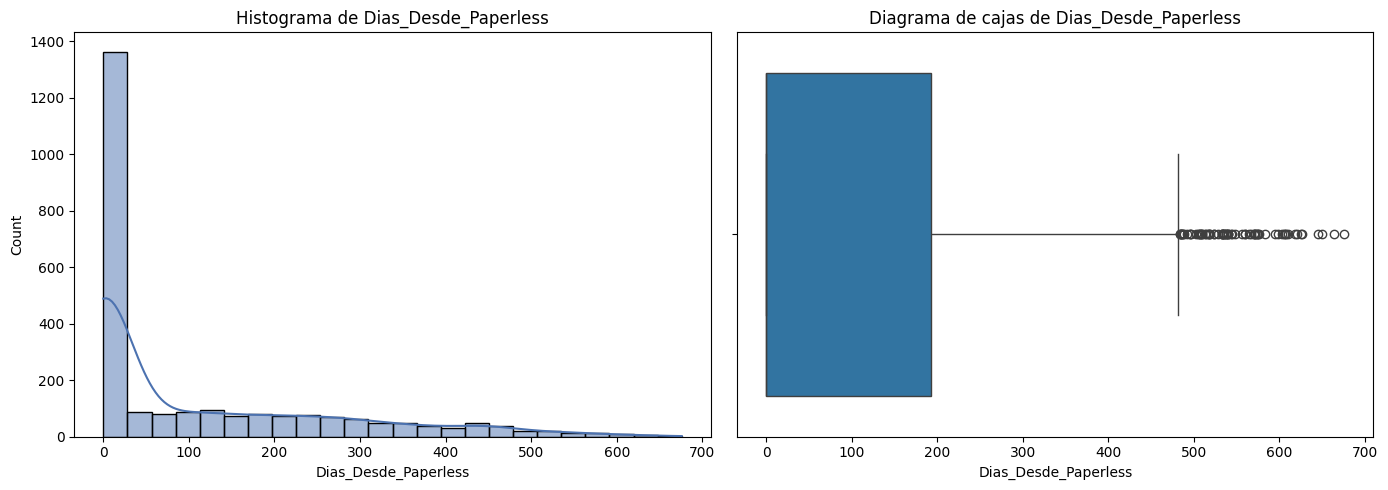

Columna: Tasa_Atraso_Historico
Asimetría (Skew): 0.52
Curtosis: -1.24


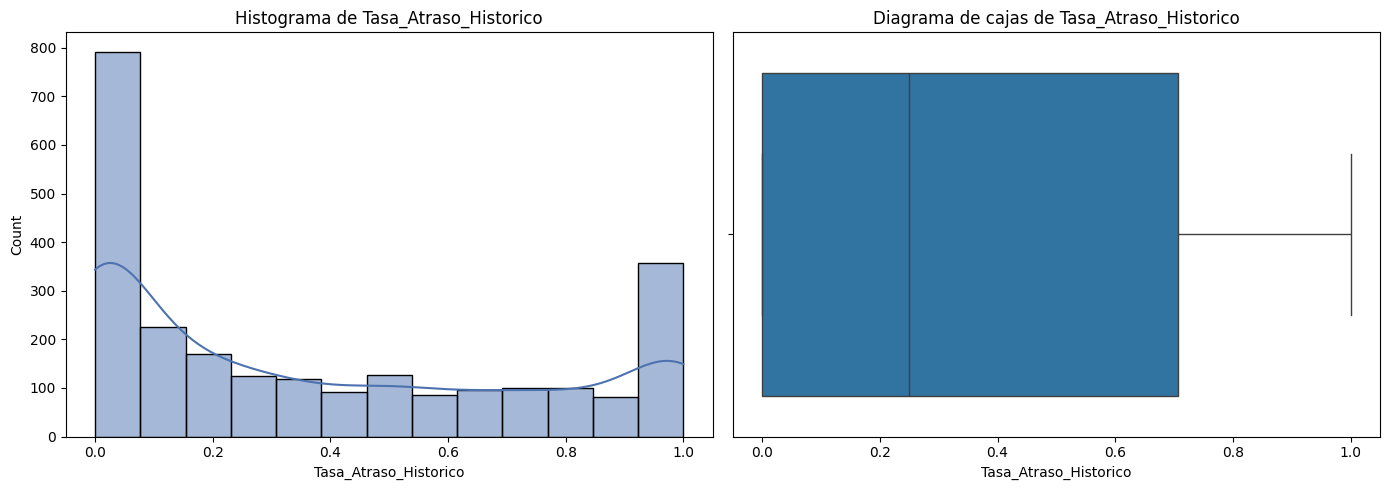

Columna: Promedio_Dias_Atraso_Historico
Asimetría (Skew): 1.48
Curtosis: 1.9


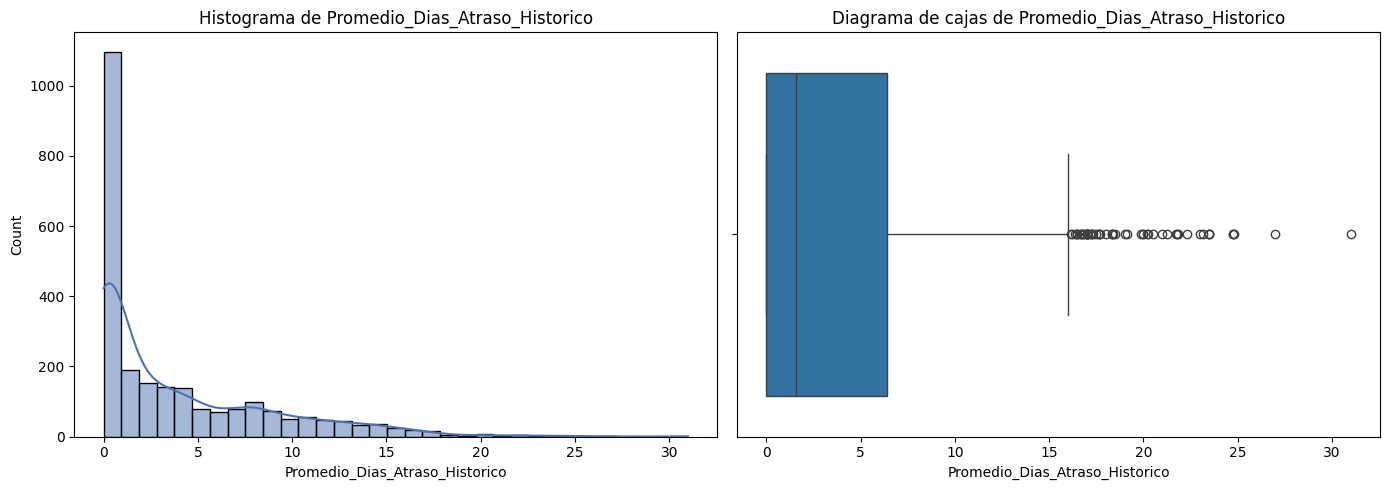

Columna: Facturas_Disputadas_Pasadas
Asimetría (Skew): 2.28
Curtosis: 5.69


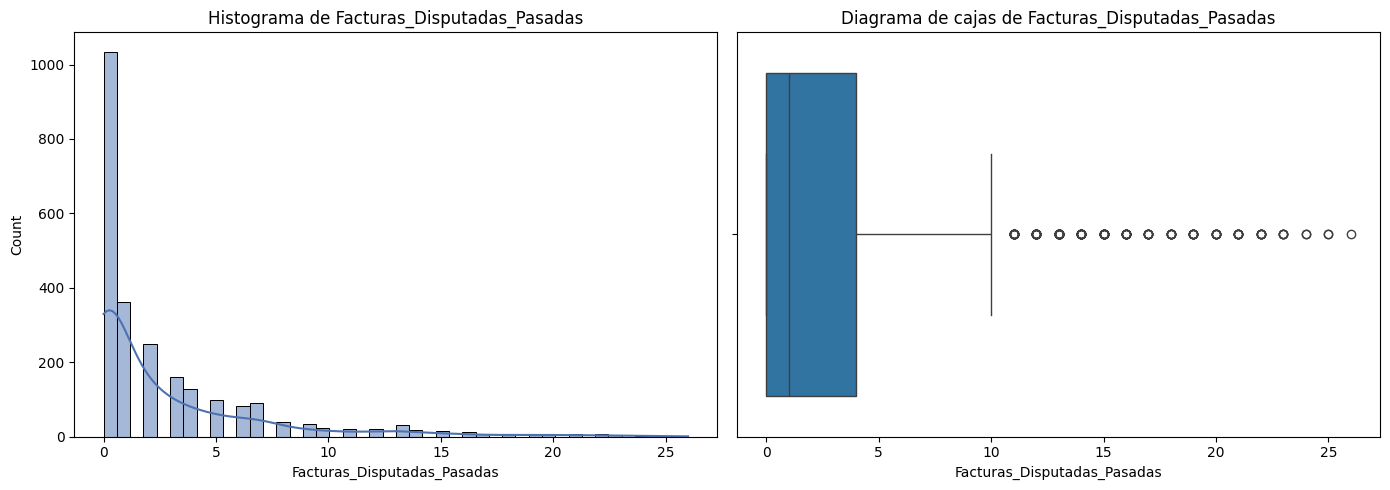

Columna: Facturas_Totales_Pasadas
Asimetría (Skew): 0.31
Curtosis: -0.74


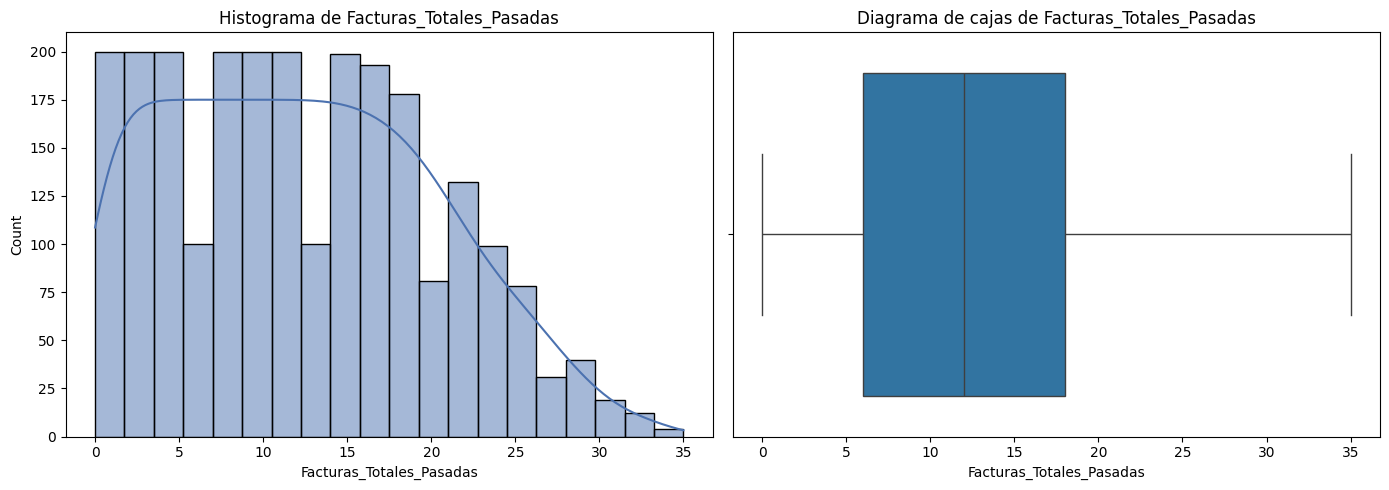

In [ ]:
# 2.1 Visualización de Variables NUMÉRICAS (Histogramas y Boxplots)
for column in vars_numericas:
    print(f'Columna: {column}')
    print(f'Asimetría (Skew): {round(df_eda[column].skew(), 2)}')
    print(f'Curtosis: {round(df_eda[column].kurtosis(), 2)}')

    plt.figure(figsize=(14, 5))

    # Histograma con curva de densidad (KDE)
    plt.subplot(1, 2, 1)
    sns.histplot(df_eda[column], kde=True, color='#4C72B0')
    plt.title(f'Histograma de {column}')

    # Diagrama de cajas (Boxplot)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_eda[column], color='C0')
    plt.title(f'Diagrama de cajas de {column}')

    plt.tight_layout()
    plt.savefig(f'/content/imagenes_eda/02.1_numericas_{column}.png', dpi=300, bbox_inches='tight')
    plt.show()

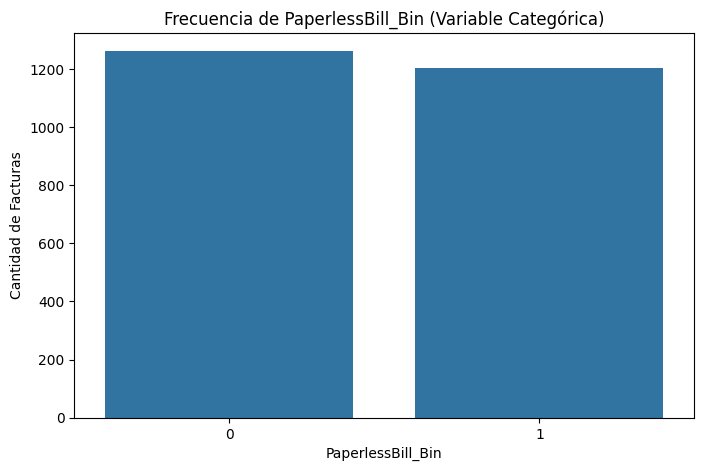

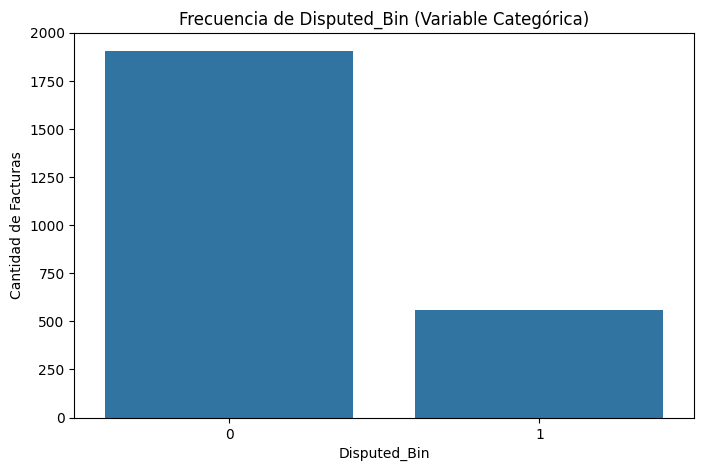

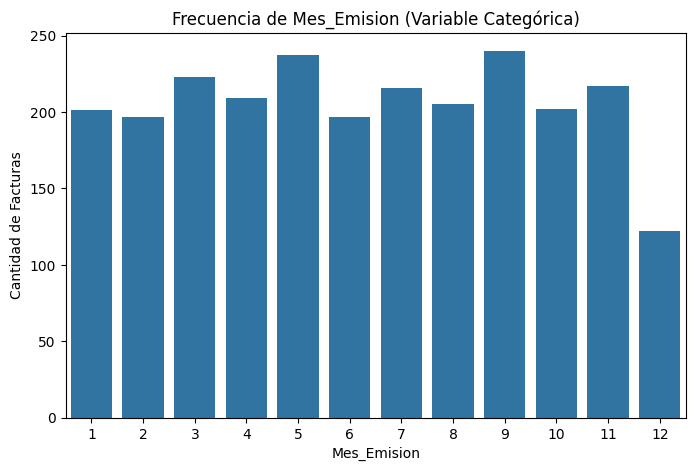

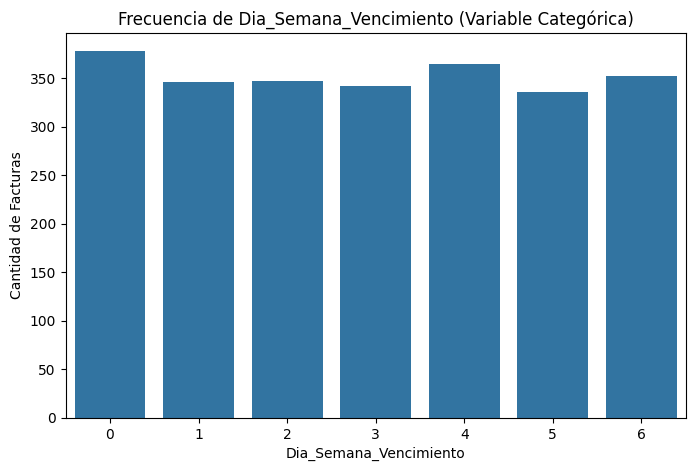

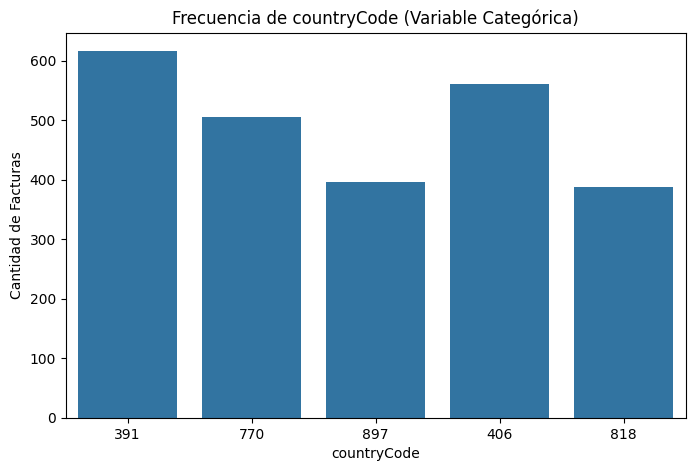

In [ ]:

# 2.2 Visualización de Variables CATEGÓRICAS (Tablas de frecuencia gráficas)
cols_cat_plot = ['PaperlessBill_Bin', 'Disputed_Bin', 'Mes_Emision', 'Dia_Semana_Vencimiento', 'countryCode']

for column in cols_cat_plot:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=column, data=df_eda)
    plt.title(f'Frecuencia de {column} (Variable Categórica)')
    plt.ylabel('Cantidad de Facturas')
    plt.xlabel(column)
    plt.savefig(f'/content/imagenes_eda/02.2_categoricas_{column}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Bloque 6: Visualización Bivariada

Mapeamos las relaciones de las variables clave frente a nuestro objetivo.

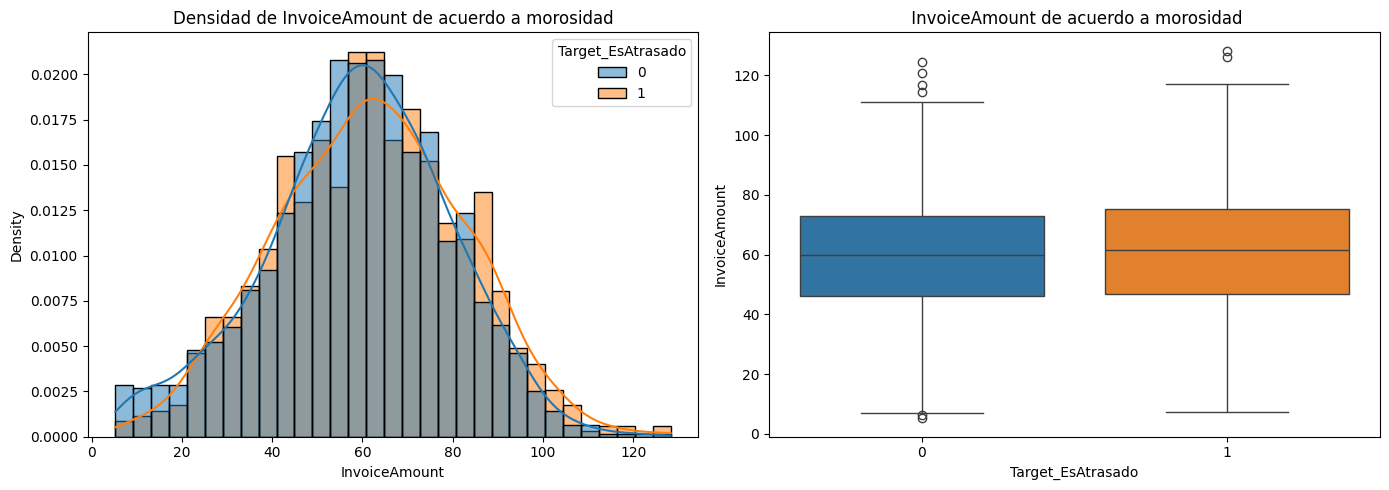

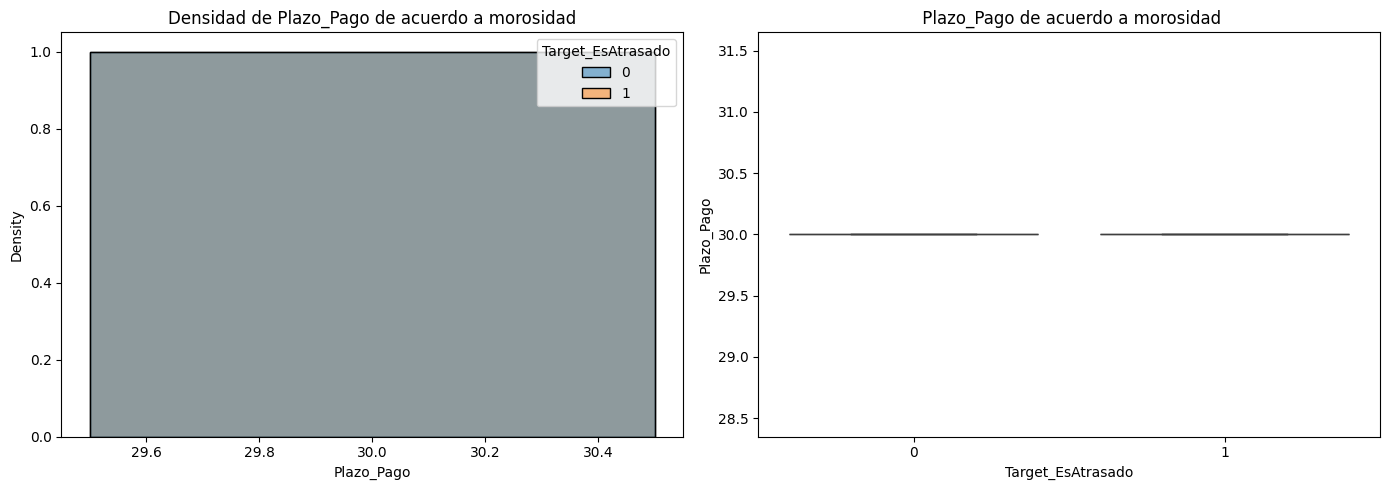

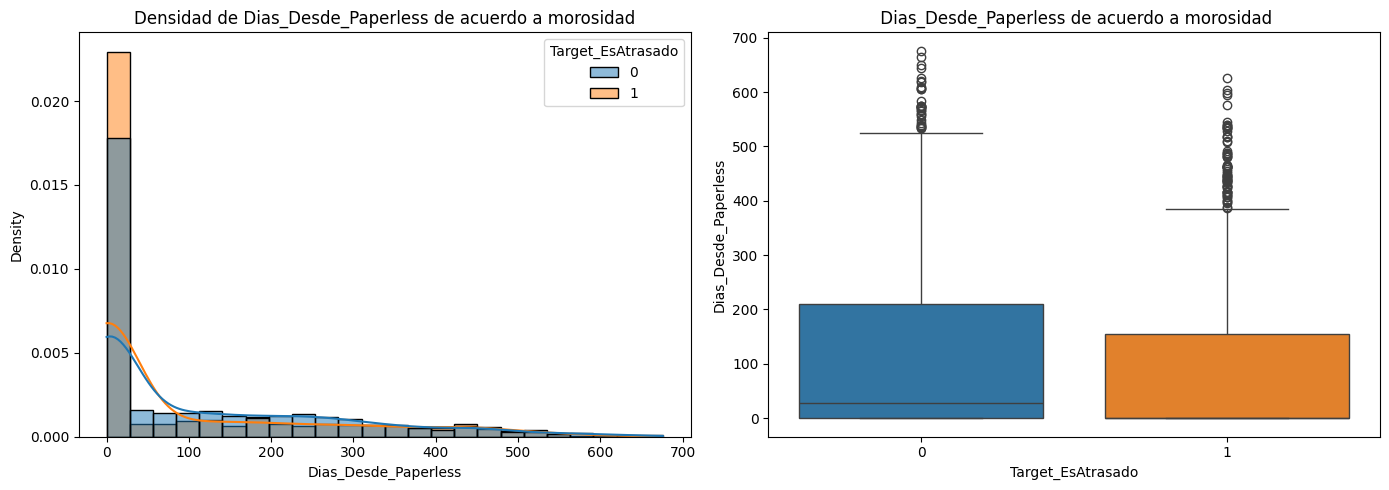

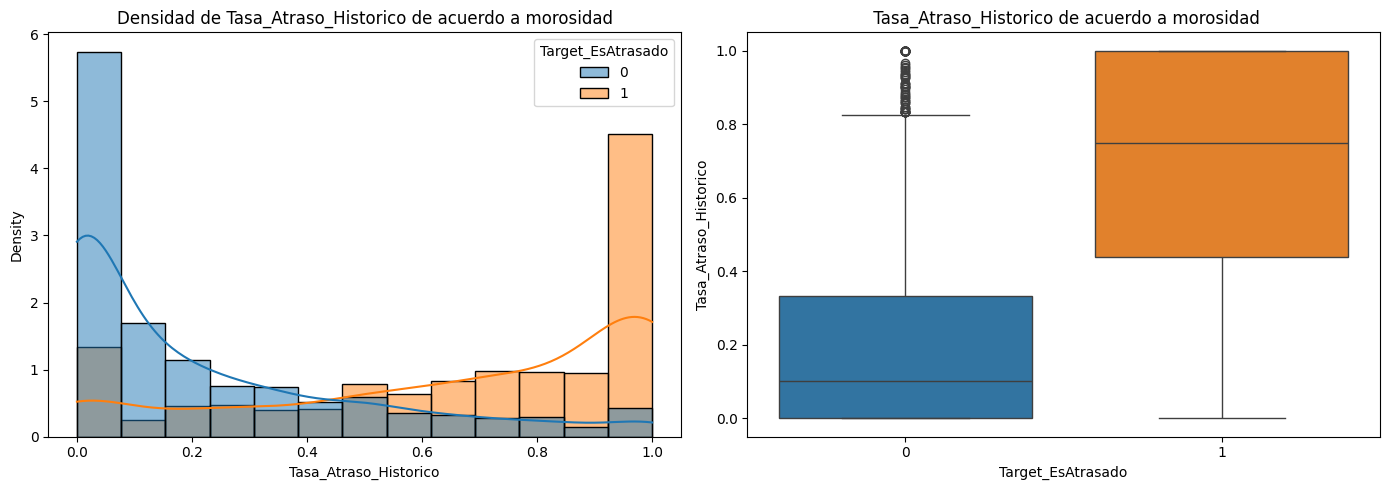

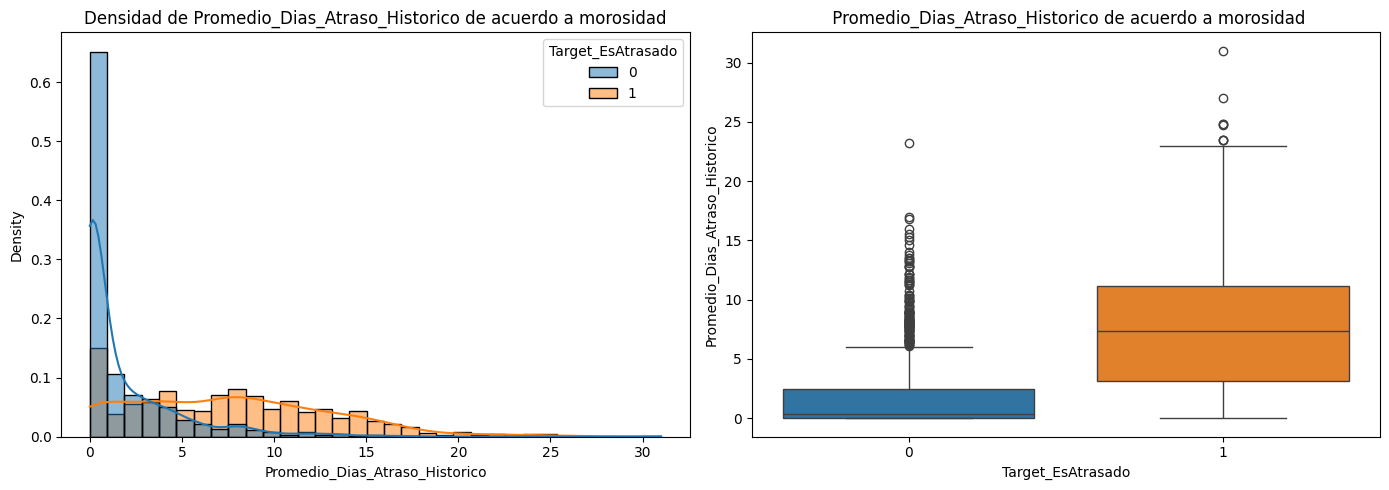

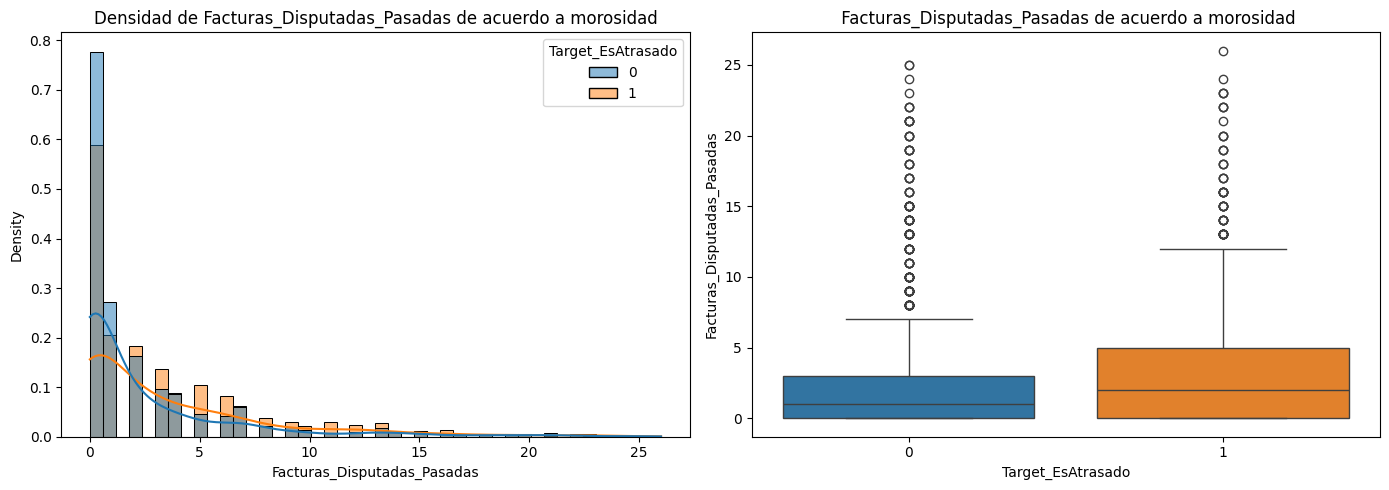

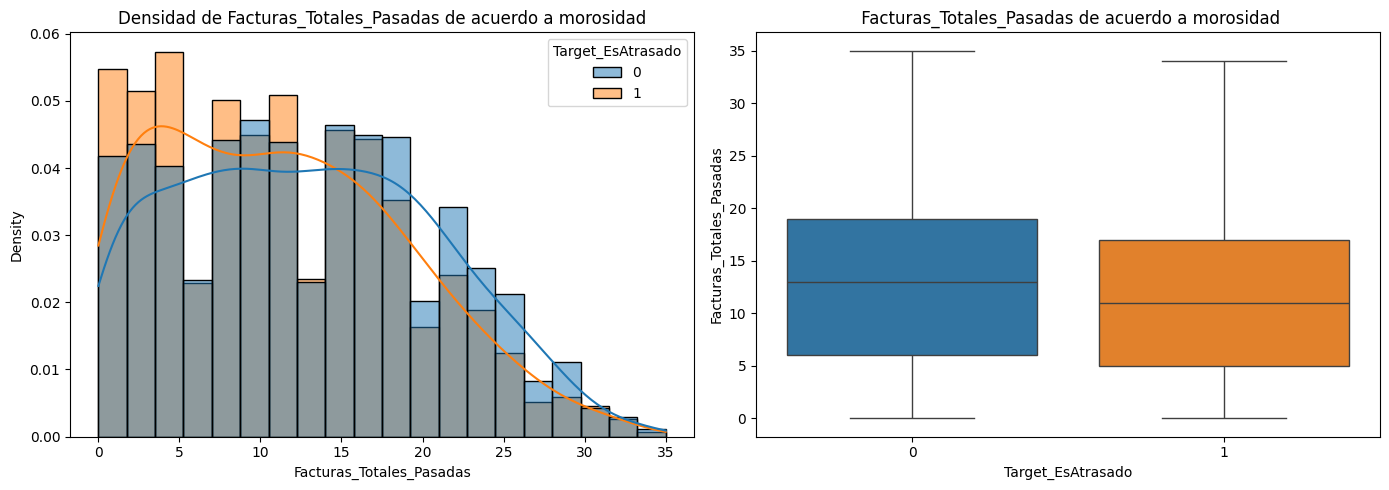

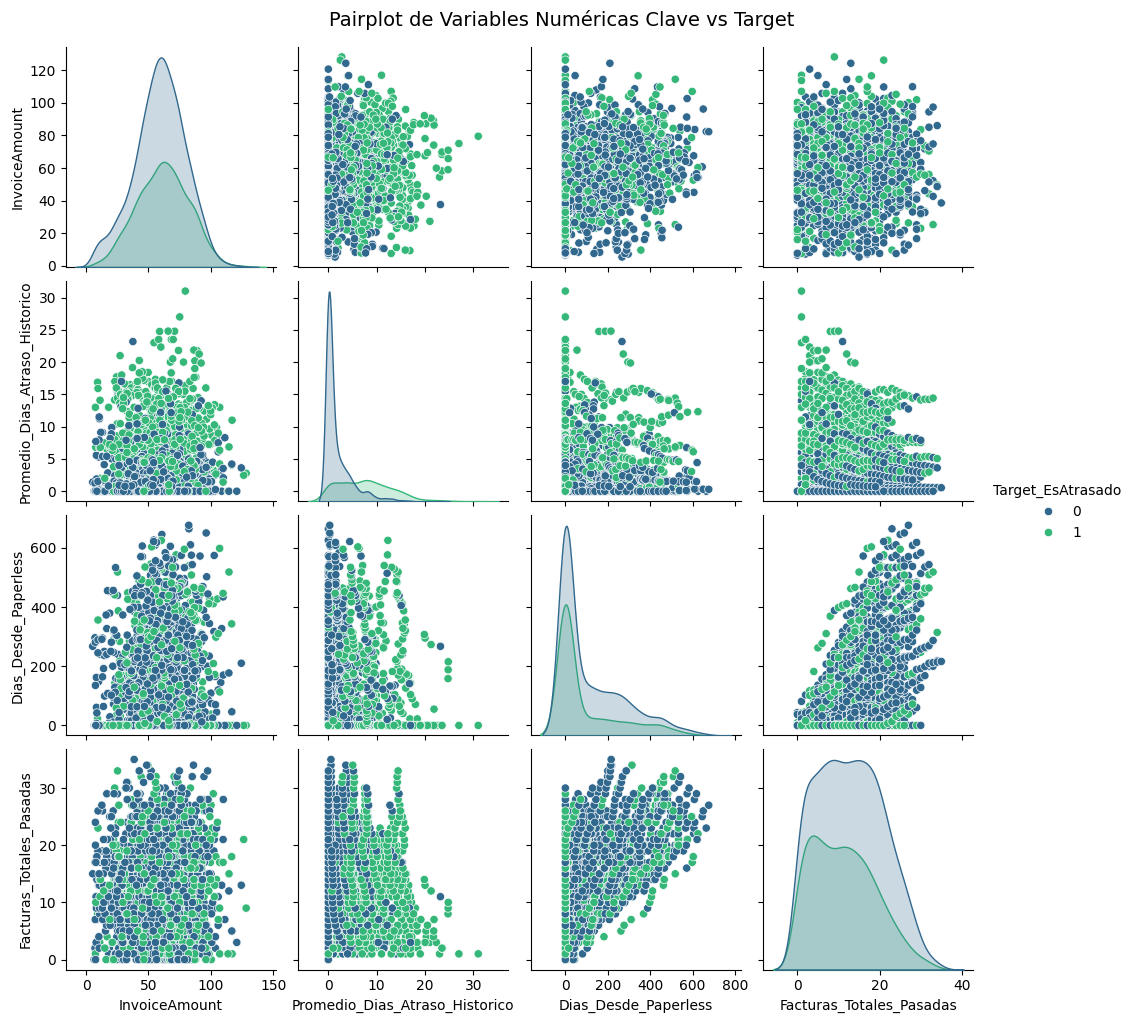

In [ ]:
# Visualización bivariada
for col in vars_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma con curva de densidad (KDE) condicionado por el Target
    sns.histplot(data=df_eda, x=col, hue='Target_EsAtrasado', kde=True, stat='density', common_norm=False, ax=axes[0])
    axes[0].set_title(f'Densidad de {col} de acuerdo a morosidad')

    # Boxplot condicionado por el Target
    sns.boxplot(data=df_eda, x='Target_EsAtrasado', y=col, hue='Target_EsAtrasado', legend=False, ax=axes[1])
    axes[1].set_title(f' {col} de acuerdo a morosidad')

    plt.tight_layout()
    plt.savefig(f'/content/imagenes_eda/03_bivariado_numericas_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()


# Pairplot (Diagramas de dispersión)
cols_pairplot = ['InvoiceAmount', 'Promedio_Dias_Atraso_Historico', 'Dias_Desde_Paperless', 'Facturas_Totales_Pasadas', 'Target_EsAtrasado']

sns.pairplot(data=df_eda[cols_pairplot], hue='Target_EsAtrasado', diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot de Variables Numéricas Clave vs Target', y=1.02, fontsize=14)
plt.savefig('/content/imagenes_eda/03_pairplot_variables_clave.png', dpi=300, bbox_inches='tight')
plt.show()

### Bloque 7: Matriz de Correlación (Spearman)

Verificamos colinealidad inicial utilizando el método de Spearman por ser variables con distribuciones asimétricas.

In [ ]:
# @title
# # @title
# # Removemos variables categóricas puras para la correlación
# df_cor = df_eda.drop(columns=['countryCode'])

# # Calculamos correlación
# correlation_matrix = df_cor.corr(method='spearman')

# # Gráfica
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', vmin=-1, vmax=1)
# plt.title('Matriz de Correlación de Spearman', fontsize=14)
# plt.tight_layout()
# plt.savefig('/content/imagenes_eda/04_matriz_correlacion_spearman.png', dpi=300, bbox_inches='tight')
# plt.show()

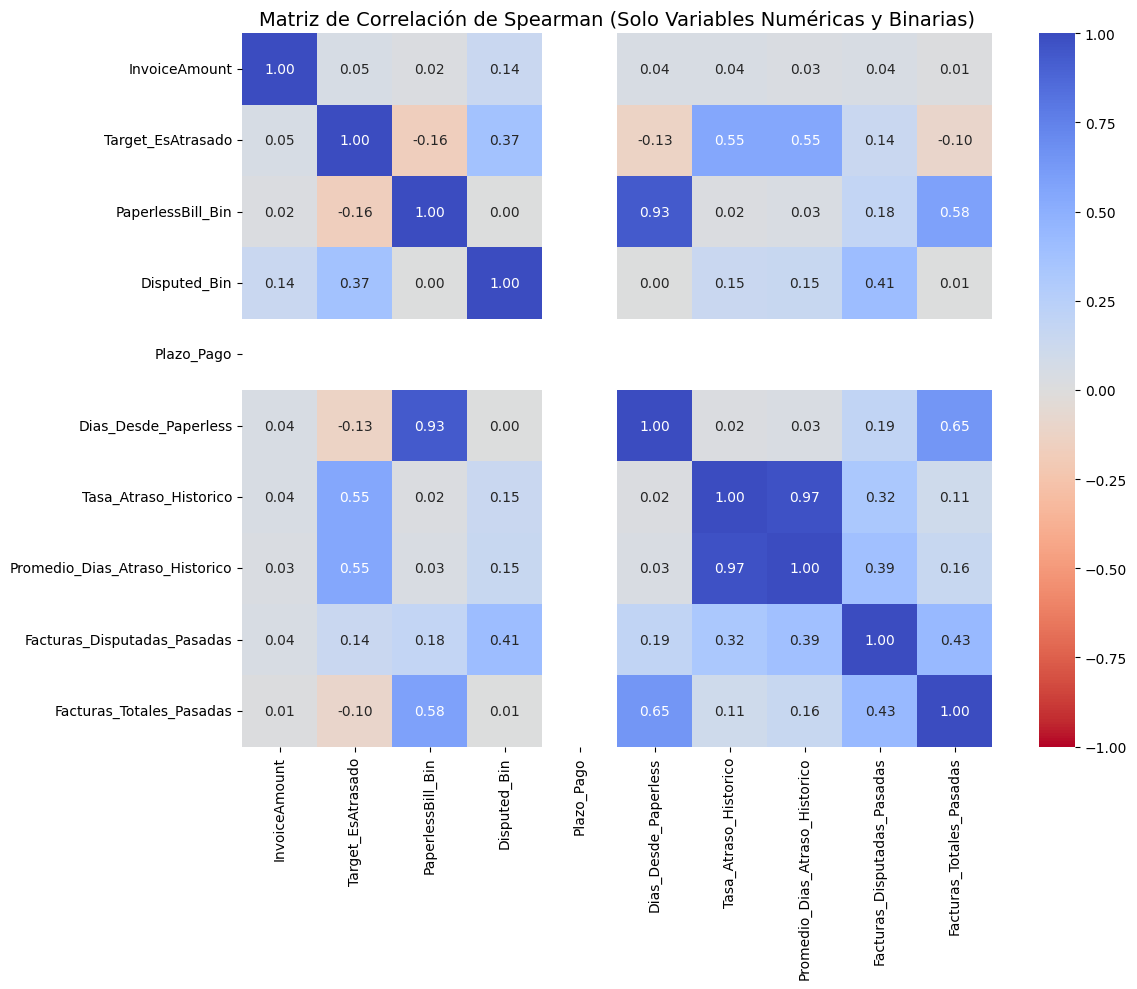

In [ ]:
# Excluimos las variables categóricas cíclicas/nominales que no tienen una progresión lineal real
cols_excluir_corr = ['countryCode', 'Mes_Emision', 'Dia_Semana_Vencimiento']
df_cor = df_eda.drop(columns=cols_excluir_corr)

# Calculamos correlación de Spearman (solo numéricas y binarias)
correlation_matrix = df_cor.corr(method='spearman')

# Gráfica
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Spearman (Solo Variables Numéricas y Binarias)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/imagenes_eda/04n_matriz_correlacion_spearman.png', dpi=300, bbox_inches='tight')
plt.show()

### Bloque 8: Análisis de VIF y Selección Final de Variables

Calculamos el Factor de Inflación de la Varianza (VIF) aplicando *One-Hot Encoding* preventivo a la variable país, y tomamos decisiones finales.

In [ ]:
# @title
# # @title
# # 1. Separar características independientes (X)
# X_completo = df_eda.drop(columns=['Target_EsAtrasado'])
# col_categoricas = ['countryCode']
# col_numericas = X_completo.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()

# # 2. Codificar variables categóricas
# encoder_ini = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
# X_cat_encoded = encoder_ini.fit_transform(X_completo[col_categoricas])
# nombres_cat = encoder_ini.get_feature_names_out(col_categoricas)

# X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_completo.index)
# X_unificado = pd.concat([X_completo[col_numericas], X_cat_df], axis=1)

# # 3. Calcular VIF
# X_vif = X_unificado.copy()
# X_vif['intercept'] = 1
# vif_data = pd.DataFrame()
# vif_data["Variable"] = X_vif.columns
# vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# # Ordenar de mayor a menor peligro
# vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)
# print(" PRIMER VIF (EVALUACIÓN DE MULTICOLINEALIDAD) ")
# print(vif_data.to_string(index=False))

# # - SELECCIÓN FINAL -
# # Tras evaluar el VIF y la correlación, eliminamos 'Plazo_Pago' (constante de 30 días, VIF 0)
# # y 'Tasa_Atraso_Historico' (VIF > 5) para evitar redundancia y multicolinealidad severa.
# # También 'PaperlessBill_Bin' por estar capturada en 'Dias_Desde_Paperless'.

columnas_definitivas = [
    'Target_EsAtrasado', 'countryCode', 'InvoiceAmount', 'Disputed_Bin',
    'Dias_Desde_Paperless', 'Mes_Emision', 'Dia_Semana_Vencimiento',
    'Promedio_Dias_Atraso_Historico', 'Facturas_Disputadas_Pasadas',
    'Facturas_Totales_Pasadas'
]

df_final = df_eda[columnas_definitivas]

print(f"Dimensiones finales: {df_final.shape}")


Dimensiones finales: (2466, 10)


In [ ]:
# 1. Separar características independientes (X)
X_completo = df_eda.drop(columns=['Target_EsAtrasado'])

# AHORA incluimos TODAS las variables categóricas (nominales y cíclicas) en el bloque de codificación
col_categoricas_vif = ['countryCode', 'Mes_Emision', 'Dia_Semana_Vencimiento']
col_numericas_vif = X_completo.drop(columns=col_categoricas_vif).columns.tolist()

# 2. Codificar variables categóricas (One-Hot Encoding)
encoder_ini = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder_ini.fit_transform(X_completo[col_categoricas_vif])
nombres_cat = encoder_ini.get_feature_names_out(col_categoricas_vif)

# Unificar el dataframe con las numéricas puras y las categóricas ya transformadas a binarias
X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_completo.index)
X_unificado = pd.concat([X_completo[col_numericas_vif], X_cat_df], axis=1)

# 3. Calcular VIF
X_vif = X_unificado.copy()
X_vif['intercept'] = 1  # Requerido por la librería statsmodels
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Ordenar de mayor a menor peligro de colinealidad
vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)
print("=== VIF INICIAL (EVALUACIÓN DE MULTICOLINEALIDAD CORREGIDA) ===")
print(vif_data.to_string(index=False))

# --- SELECCIÓN DEFINITIVA ---
# Tras evaluar el VIF y la correlación real, eliminamos 'Plazo_Pago' (constante de 30 días, VIF 0)
# y 'Tasa_Atraso_Historico' (VIF > 5) para evitar redundancia severa.
# También 'PaperlessBill_Bin' por estar directamente capturada en 'Dias_Desde_Paperless'.

columnas_definitivas = [
    'Target_EsAtrasado', 'countryCode', 'InvoiceAmount', 'Disputed_Bin',
    'Dias_Desde_Paperless', 'Mes_Emision', 'Dia_Semana_Vencimiento',
    'Promedio_Dias_Atraso_Historico', 'Facturas_Disputadas_Pasadas',
    'Facturas_Totales_Pasadas'
]

df_final = df_eda[columnas_definitivas]

df_final.to_csv('acData_Modelado_Final.csv', index=False)
print(f"Dimensiones finales: {df_final.shape}")

=== VIF INICIAL (EVALUACIÓN DE MULTICOLINEALIDAD CORREGIDA) ===
                      Variable      VIF
         Tasa_Atraso_Historico 5.314729
Promedio_Dias_Atraso_Historico 5.292233
          Dias_Desde_Paperless 2.461467
      Facturas_Totales_Pasadas 2.309239
             PaperlessBill_Bin 2.227299
                 Mes_Emision_9 2.102187
                Mes_Emision_11 2.068578
                 Mes_Emision_5 2.011725
                Mes_Emision_10 1.962509
                 Mes_Emision_7 1.953155
                 Mes_Emision_3 1.946661
                 Mes_Emision_8 1.936280
                 Mes_Emision_4 1.906252
                 Mes_Emision_6 1.871114
   Facturas_Disputadas_Pasadas 1.860927
                 Mes_Emision_2 1.839770
               countryCode_406 1.714852
      Dia_Semana_Vencimiento_4 1.692888
               countryCode_897 1.673877
      Dia_Semana_Vencimiento_2 1.672334
      Dia_Semana_Vencimiento_6 1.667760
      Dia_Semana_Vencimiento_1 1.665209
      Dia_Semana

In [ ]:
#Para añadir imagenes al latex
!zip -r /content/imagenes3.zip /content/imagenes_eda


updating: content/imagenes_eda/ (stored 0%)
updating: content/imagenes_eda/03_bivariado_numericas_Dias_Desde_Paperless.png (deflated 19%)
updating: content/imagenes_eda/03_bivariado_numericas_Tasa_Atraso_Historico.png (deflated 18%)
updating: content/imagenes_eda/02.1_numericas_Dias_Desde_Paperless.png (deflated 24%)
updating: content/imagenes_eda/03_bivariado_numericas_Promedio_Dias_Atraso_Historico.png (deflated 17%)
updating: content/imagenes_eda/02.2_categoricas_PaperlessBill_Bin.png (deflated 27%)
updating: content/imagenes_eda/03_bivariado_numericas_Facturas_Disputadas_Pasadas.png (deflated 19%)
updating: content/imagenes_eda/02.2_categoricas_countryCode.png (deflated 24%)
updating: content/imagenes_eda/02.1_numericas_InvoiceAmount.png (deflated 19%)
updating: content/imagenes_eda/02.2_categoricas_Dia_Semana_Vencimiento.png (deflated 24%)
updating: content/imagenes_eda/02.2_categoricas_Mes_Emision.png (deflated 26%)
updating: content/imagenes_eda/02.2_categoricas_Disputed_Bin.png

In [ ]:
from google.colab import files
files.download('/content/imagenes3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
import shutil

# 1. Esto abrirá la ventana flotante para conectar tu Google Drive
drive.mount('/content/drive')

# 2. Copia tu archivo ZIP (reemplaza "tu_archivo.zip" por el nombre real de tu archivo)
# Si tu archivo está en la carpeta por defecto de Colab, la ruta es '/content/tu_archivo.zip'
shutil.copy('/content/tu_archivo.zip', '/content/drive/MyDrive/tu_archivo.zip')

print("¡Listo! El archivo se copió correctamente a tu Google Drive.")

MessageError: Error: credential propagation was unsuccessful